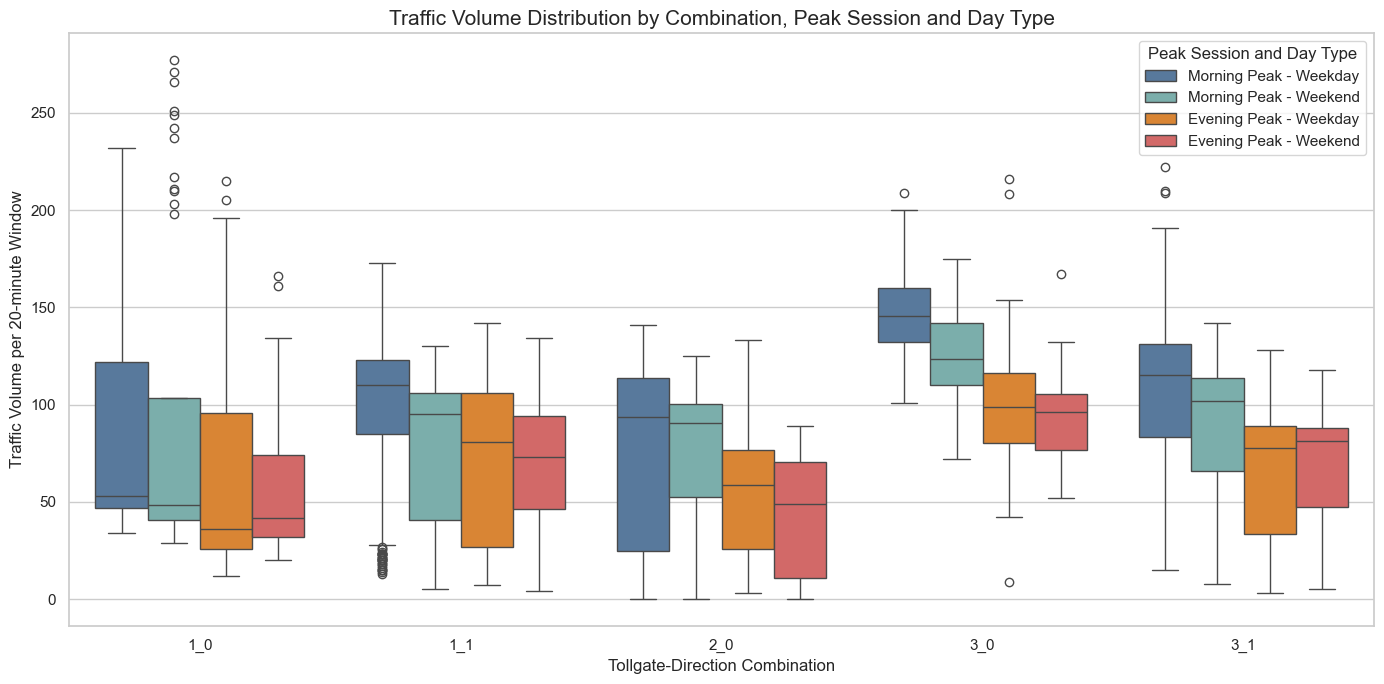

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取 20 分钟聚合后的训练流量数据
df = pd.read_csv(
    "/Users/caster/Desktop/数据与算法大作业/data/processed/volume_train_20min.csv"
)

# 确保时间字段为 datetime
df["time_window_start"] = pd.to_datetime(df["time_window_start"])

# 提取时间字段
df["hour"] = df["time_window_start"].dt.hour
df["weekday"] = df["time_window_start"].dt.weekday

# 构造收费站-方向组合标签
df["combo"] = (
    df["tollgate_id"].astype(str)
    + "_"
    + df["direction"].astype(str)
)

# 只保留题目要求的 5 个组合
valid_combos = ["1_0", "1_1", "2_0", "3_0", "3_1"]
df = df[df["combo"].isin(valid_combos)].copy()

# 标记早晚高峰
df["peak_session"] = df["hour"].apply(
    lambda h: "Morning Peak" if h in [8, 9]
    else "Evening Peak" if h in [17, 18]
    else "Other"
)

# 只保留早晚高峰
plot_df = df[df["peak_session"].isin(["Morning Peak", "Evening Peak"])].copy()

# 标记工作日/周末
plot_df["day_type"] = plot_df["weekday"].apply(
    lambda x: "Weekend" if x in [5, 6] else "Weekday"
)

# 组合成 4 类标签
plot_df["session_day_type"] = (
    plot_df["peak_session"] + " - " + plot_df["day_type"]
)

# 固定图例顺序
hue_order = [
    "Morning Peak - Weekday",
    "Morning Peak - Weekend",
    "Evening Peak - Weekday",
    "Evening Peak - Weekend",
]

# 绘图风格
sns.set_theme(style="whitegrid", font="Arial")

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=plot_df,
    x="combo",
    y="volume",
    hue="session_day_type",
    order=valid_combos,
    hue_order=hue_order,
    palette={
        "Morning Peak - Weekday": "#4C78A8",
        "Morning Peak - Weekend": "#72B7B2",
        "Evening Peak - Weekday": "#F58518",
        "Evening Peak - Weekend": "#E45756",
    },
    showfliers=True
)

plt.title(
    "Traffic Volume Distribution by Combination, Peak Session and Day Type",
    fontsize=15
)
plt.xlabel("Tollgate-Direction Combination", fontsize=12)
plt.ylabel("Traffic Volume per 20-minute Window", fontsize=12)
plt.legend(
    title="Peak Session and Day Type",
    loc="upper right"
)

plt.tight_layout()
plt.show()